In [1]:
import pandas as pd

from src.VideoIngestor import augment_dataset
from pathlib import Path
from utils.plot import plotTrainResults

from utils.constants import VALIDATION_CSV
from utils.constants import BASELINE_CONFIG
baseline_train = BASELINE_CONFIG


In [2]:
df_p1 = pd.read_csv(Path("data/phase1_train.csv"))

histology_freqs = df_p1["histology"].value_counts()

print(histology_freqs)

histology
Adenoma                     1515
Sessile_serrated_adenoma     671
Hyperplastic                 319
Adenocarcinoma               100
Name: count, dtype: int64


In [3]:
phase2 = False

if phase2:
    augment_dataset(r"utils/models/Kvasir_yolov8m.pt")

In [4]:
phase2_csv_dir = Path('data/phase2/phase2_train.csv')

histology_freqs = pd.read_csv(phase2_csv_dir)["histology"].value_counts()

print(histology_freqs)

histology
Adenoma                     2792
Sessile_serrated_adenoma    2440
Hyperplastic                1668
Adenocarcinoma               715
Name: count, dtype: int64


Hardware assigned for tensor computations: cuda
Training metadata: C:\Users\luis\Documents\TFG - Data-Centric AI\data\phase2\phase2_train.csv
Validation metadata: C:\Users\luis\Documents\TFG - Data-Centric AI\data\validation.csv
Train class distribution:
histology
Adenoma                     2792
Sessile_serrated_adenoma    2440
Hyperplastic                1668
Adenocarcinoma               715

Validation class distribution:
histology
Adenoma                     379
Sessile_serrated_adenoma    168
Hyperplastic                 80
Adenocarcinoma               20

Loss weights: {'Adenoma': 0.5179, 'Sessile_serrated_adenoma': 0.5927, 'Hyperplastic': 0.8669, 'Adenocarcinoma': 2.0225}
Initiating training phase. Saving results to: C:\Users\luis\Documents\TFG - Data-Centric AI\results\phase2


Training Progress:   3%|▎         | 3/100 [10:29<5:35:02, 207.25s/epoch, Stage=head_only, Train Loss=0.6295, Val Loss=1.2385, Val F1=0.3988, LR=1.0e-03]        


Switching to full-network fine-tuning at epoch 4.


Training Progress:  50%|█████     | 50/100 [3:02:15<3:02:15, 218.71s/epoch, Stage=full_network, Train Loss=0.1757, Val Loss=1.4582, Val F1=0.5604, LR=2.5e-06/2.5e-05]        
c:\Users\luis\Documents\TFG - Data-Centric AI\src\ModelTrain.py:847: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have fu


Early stopping triggered after 12 epochs without improving macro-F1.

Optimization sequence completed. Best validation macro-F1: 0.5617 at epoch 39.
Artifacts successfully written to 'C:\Users\luis\Documents\TFG - Data-Centric AI\results\phase2'.


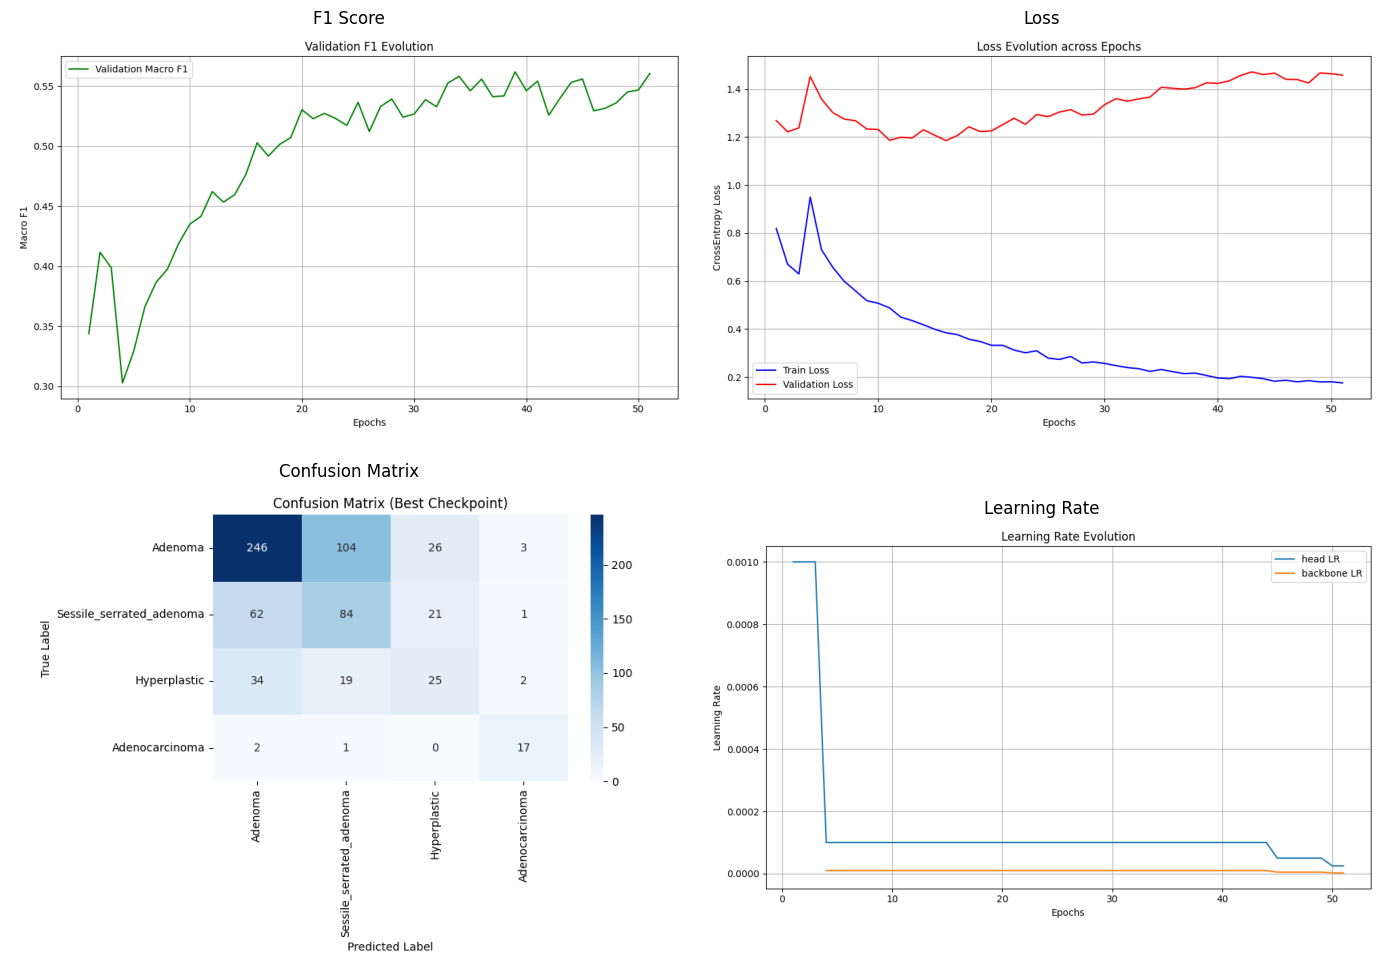

=== GLOBAL METRICS ===
Accuracy:          0.5750
Balanced Accuracy: 0.5779
Macro F1:          0.5617
Weighted F1:       0.5798

=== PER-CLASS METRICS ===
                          precision    recall  f1-score   support

                 Adenoma     0.7151    0.6491    0.6805       379
Sessile_serrated_adenoma     0.4038    0.5000    0.4468       168
            Hyperplastic     0.3472    0.3125    0.3289        80
          Adenocarcinoma     0.7391    0.8500    0.7907        20

                accuracy                         0.5750       647
               macro avg     0.5513    0.5779    0.5617       647
            weighted avg     0.5895    0.5750    0.5798       647



In [5]:
baseline_train.random_state = 42

phase2_img_dir = Path("phase2/frames")
phase2_csv_dir = Path("phase2/phase2_train.csv")
phase2_validation_csv_dir = VALIDATION_CSV
phase2_validation_img_dir = Path("unified_images")
phase2_dir = Path('phase2')

plotTrainResults(
    train_csv_dir=phase2_csv_dir,
    validation_csv_dir=phase2_validation_csv_dir,
    train_img_dir=phase2_img_dir,
    validation_img_dir=phase2_validation_img_dir,
    results_dir=phase2_dir,
    train=baseline_train,
)